C:\Users\EDWIN\AppData\Local\Temp\ipykernel_14548\1582757681.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM telemetria_camiones", conn)


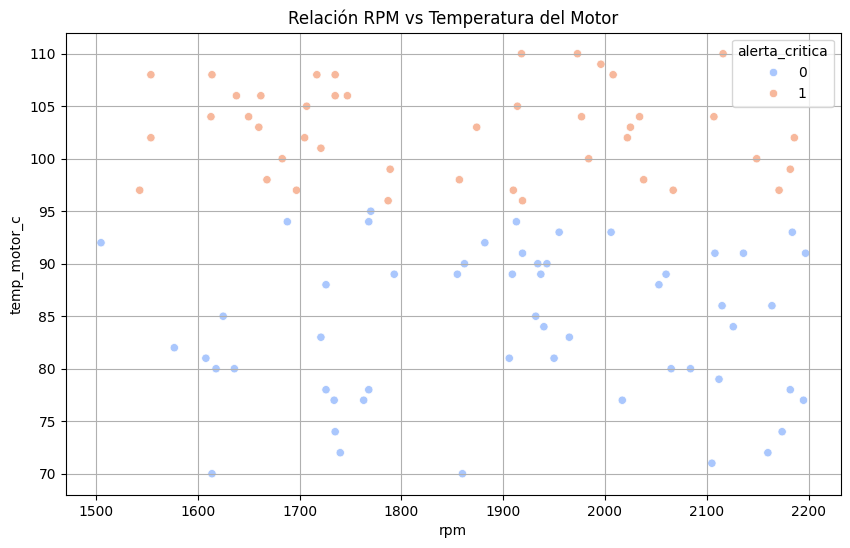

Nivel promedio de combustible por unidad:
camion_id
CAT-797-001    55.551237
Name: nivel_combustible_pct, dtype: float64


In [2]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conexión a tu Warehouse (Capa Silver)
conn = mysql.connector.connect(
    host="127.0.0.1", user="root", password="", database="db_mineria_smart"
)

# 2. Carga de datos para análisis
df = pd.read_sql("SELECT * FROM telemetria_camiones", conn)
conn.close()

# 3. Limpieza rápida (Data Quality)
df['timestamp_reporte'] = pd.to_datetime(df['timestamp_reporte'])

# 4. Visualización: Correlación entre RPM y Temperatura
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rpm', y='temp_motor_c', hue='alerta_critica', palette='coolwarm')
plt.title('Relación RPM vs Temperatura del Motor')
plt.grid(True)
plt.show()

# 5. Análisis de Consumo: Promedio de combustible por camión
resumen = df.groupby('camion_id')['nivel_combustible_pct'].mean()
print("Nivel promedio de combustible por unidad:")
print(resumen)